In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os
import csv



IMAGE_DIR = "/content/drive/MyDrive/BAD MANGOES1"     # Input folder
OUTPUT_DIR = "/content/drive/MyDrive/BAD MANGOES SEGMENTED_2"       # Output folder
CSV_PATH = os.path.join(OUTPUT_DIR, "damage_report_segmented.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

K = 4
POST_KERNEL = 5

In [3]:

def keep_largest_region(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    if num_labels <= 1:
        return mask
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    filtered = np.zeros_like(mask)
    filtered[labels == largest_label] = 1
    return filtered


def morphological_clean(mask, kernel_size=POST_KERNEL):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    cleaned = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    return cleaned


In [4]:


def estimate_fruit_mask(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (7,7), 0)

    th = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 21, 2)
    mask = (th == 255).astype(np.uint8)

    mask = morphological_clean(mask, kernel_size=11)
    mask = keep_largest_region(mask)

    h, w = gray.shape
    area = mask.sum()
    if area < 0.02 * h * w or area > 0.98 * h * w:
        mask = 1 - mask

    if mask.sum() == 0:
        return np.ones_like(gray, dtype=np.uint8)
    return mask


In [5]:

def calculate_damage_percentage_from_clusters(gray_clusters, gray_mask, fruit_mask):

    fruit_mask = (fruit_mask > 0).astype(np.uint8)

    cluster_means = []
    cluster_counts = []

    for cluster_idx in range(len(gray_clusters)):
        cluster_region = (gray_mask == cluster_idx) & (fruit_mask == 1)
        count = np.count_nonzero(cluster_region)
        if count == 0:
            cluster_means.append(255)
        else:
            mean_intensity = np.mean(gray_clusters[cluster_idx])
            cluster_means.append(mean_intensity)
        cluster_counts.append(count)

    damage_cluster = np.argmin(cluster_means)

    damage_pixels = cluster_counts[damage_cluster]
    total_fruit_pixels = np.count_nonzero(fruit_mask)

    if total_fruit_pixels == 0:
        return 0.0

    damage_pct = (damage_pixels / total_fruit_pixels) * 100.0
    return float(np.clip(damage_pct, 0, 100))



In [6]:


def colorize_clusters(segmented, n_clusters, grayscale=False):
    """Convert segmented clusters to displayable RGB image.
       If grayscale=True, output shades of gray."""
    h, w = segmented.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    if grayscale:
        gray_values = np.linspace(50, 200, n_clusters).astype(np.uint8)
        for i in range(n_clusters):
            out[segmented == i] = [gray_values[i]] * 3
    else:
        cmap = plt.get_cmap('tab10')
        for i in range(n_clusters):
            color = np.array(cmap(i)[:3]) * 255
            out[segmented == i] = color.astype(np.uint8)
    return out


def visualize_comparison(image_rgb, hsv_clusters, hsv_mask, gray_clusters, gray_mask,
                         damage_pct_hsv, damage_pct_gray, save_path=None):
    hsv_clusters_col = colorize_clusters(hsv_clusters, K, grayscale=False)
    gray_clusters_col = colorize_clusters(gray_clusters, K, grayscale=True)

    fig, axes = plt.subplots(1,5, figsize=(20,5))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Original')

    axes[1].imshow(hsv_clusters_col)
    axes[1].set_title('HSV Clusters')

    axes[2].imshow(image_rgb)
    axes[2].imshow(hsv_mask, alpha=0.4, cmap='jet')
    axes[2].set_title(f'HSV Damage ({damage_pct_hsv:.2f}%)')

    axes[3].imshow(gray_clusters_col, cmap='gray')
    axes[3].set_title('Gray Clusters')

    axes[4].imshow(image_rgb)
    axes[4].imshow(gray_mask, alpha=0.4, cmap='jet')
    axes[4].set_title(f'Gray Damage ({damage_pct_gray:.2f}%)')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


In [7]:

def segment_kmeans_hsv(image_bgr, k=K, post_kernel=POST_KERNEL):
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w, _ = image_hsv.shape
    pixels = image_hsv.reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    segmented = labels.reshape(h, w)

    cluster_means_v = []
    for i in range(k):
        mask_cluster = (segmented == i)
        mean_v = np.mean(image_hsv[:,:,2][mask_cluster]) if np.any(mask_cluster) else np.inf
        cluster_means_v.append(mean_v)


    cluster_areas = [(segmented == i).sum() for i in range(k)]
    for i, area in enumerate(cluster_areas):
        if area < 0.01 * h * w:
            cluster_means_v[i] = np.inf

    damage_cluster = int(np.argmin(cluster_means_v))
    mask = (segmented == damage_cluster).astype(np.uint8)
    mask = morphological_clean(mask, kernel_size=post_kernel)
    mask = keep_largest_region(mask)
    return segmented, mask


def segment_kmeans_gray(image_bgr, k=K, post_kernel=POST_KERNEL):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    pixels = gray.reshape(-1, 1)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    segmented = labels.reshape(h, w)

    cluster_means = []
    for i in range(k):
        mask_cluster = (segmented == i)
        mean_i = np.mean(gray[mask_cluster]) if np.any(mask_cluster) else np.inf
        cluster_means.append(mean_i)

    cluster_areas = [(segmented == i).sum() for i in range(k)]
    for i, area in enumerate(cluster_areas):
        if area < 0.01 * h * w:
            cluster_means[i] = np.inf

    damage_cluster = int(np.argmin(cluster_means))
    mask = (segmented == damage_cluster).astype(np.uint8)
    mask = morphological_clean(mask, kernel_size=post_kernel)
    mask = keep_largest_region(mask)
    return segmented, mask


In [8]:

image_files = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)
               if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

with open(CSV_PATH, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Image', 'HSV Damage (%)', 'Gray Damage (%)'])

    for idx, img_path in enumerate(image_files, 1):
        name = os.path.basename(img_path)
        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        fruit_mask = estimate_fruit_mask(image_rgb)

        hsv_clusters, hsv_mask = segment_kmeans_hsv(image_bgr)
        gray_clusters, gray_mask = segment_kmeans_gray(image_bgr)


        hsv_mask = hsv_mask * fruit_mask
        gray_mask = gray_mask * fruit_mask

        damage_pct_hsv = calculate_damage_percentage_from_clusters(hsv_clusters, hsv_mask, fruit_mask)
        damage_pct_gray = calculate_damage_percentage_from_clusters(gray_clusters, gray_mask, fruit_mask)

        out_path = os.path.join(OUTPUT_DIR, f"{os.path.splitext(name)[0]}_comparison_fixed.jpg")
        visualize_comparison(image_rgb, hsv_clusters, hsv_mask,
                             gray_clusters, gray_mask,
                             damage_pct_hsv, damage_pct_gray,
                             save_path=out_path)

        writer.writerow([name, f"{damage_pct_hsv:.2f}", f"{damage_pct_gray:.2f}"])
        print(f"[{idx}/{len(image_files)}] {name} → HSV={damage_pct_hsv:.2f}% | Gray={damage_pct_gray:.2f}%")

print(" Processing complete!")
print(f"Results saved in: {OUTPUT_DIR}")
print(f"CSV report: {CSV_PATH}")

[1/1500] 822.jpg → HSV=99.39% | Gray=99.46%
[2/1500] 810.jpg → HSV=1.00% | Gray=99.33%
[3/1500] 832.jpg → HSV=100.00% | Gray=99.99%
[4/1500] 825.jpg → HSV=99.92% | Gray=100.00%
[5/1500] 817.jpg → HSV=99.76% | Gray=100.00%
[6/1500] 812.jpg → HSV=99.28% | Gray=99.62%
[7/1500] 806.jpg → HSV=99.99% | Gray=100.00%
[8/1500] 849.jpg → HSV=99.56% | Gray=99.97%
[9/1500] 833.jpg → HSV=99.96% | Gray=100.00%
[10/1500] 808.jpg → HSV=93.08% | Gray=100.00%
[11/1500] 850.jpg → HSV=99.98% | Gray=100.00%
[12/1500] 838.jpg → HSV=99.45% | Gray=99.91%
[13/1500] 779.jpg → HSV=100.00% | Gray=100.00%
[14/1500] 782.jpg → HSV=99.12% | Gray=99.54%
[15/1500] 791.jpg → HSV=99.99% | Gray=100.00%
[16/1500] 798.jpg → HSV=99.62% | Gray=99.86%
[17/1500] 774.jpg → HSV=99.97% | Gray=100.00%
[18/1500] 787.jpg → HSV=0.96% | Gray=100.00%
[19/1500] 794.jpg → HSV=99.98% | Gray=99.99%
[20/1500] 795.jpg → HSV=99.06% | Gray=100.00%
[21/1500] 793.jpg → HSV=100.00% | Gray=100.00%
[22/1500] 797.jpg → HSV=0.05% | Gray=100.00%
[23/15

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [10]:
CSV_PATH = "/content/drive/MyDrive/BAD MANGOES SEGMENTED_2/damage_report_segmented.csv"
OUTPUT_DIR = "/content/drive/MyDrive/segmented EVALUATION_RESULTS 1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [13]:
df = pd.read_csv(CSV_PATH)

print("=== SUMMARY STATISTICS ===")
print(df[['HSV Damage (%)', 'Gray Damage (%)']].describe())

summary_path = os.path.join(OUTPUT_DIR, "summary_statistics.csv")
df[['HSV Damage (%)', 'Gray Damage (%)']].describe().to_csv(summary_path)
print(f"Summary saved to: {summary_path}")

=== SUMMARY STATISTICS ===
       HSV Damage (%)  Gray Damage (%)
count     1500.000000      1500.000000
mean        89.147893        98.959213
std         28.947091         5.841120
min          0.000000         0.450000
25%         98.625000        99.980000
50%         99.950000       100.000000
75%        100.000000       100.000000
max        100.000000       100.000000
Summary saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/summary_statistics.csv


In [14]:
df['Difference'] = (df['HSV Damage (%)'] - df['Gray Damage (%)']).abs()

mean_diff = df['Difference'].mean()
max_diff = df['Difference'].max()
print(f"Average absolute difference between methods: {mean_diff:.2f}%")
print(f"Largest observed difference: {max_diff:.2f}%")

largest_disagreements = df.nlargest(10, 'Difference')
disagree_path = os.path.join(OUTPUT_DIR, "largest_disagreements.csv")
largest_disagreements.to_csv(disagree_path, index=False)
print(f"Largest disagreements saved to: {disagree_path}")

largest_disagreements


Average absolute difference between methods: 10.28%
Largest observed difference: 100.00%
Largest disagreements saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/largest_disagreements.csv


,Image,HSV Damage (%),Gray Damage (%),Difference
542,52.jpg,0.00,100.0,100.00
1307,1008.jpg,0.00,100.0,100.00
387,351.jpg,0.01,100.0,99.99
421,309.jpg,0.01,100.0,99.99
524,107.jpg,0.01,100.0,99.99
742,652.jpg,0.01,100.0,99.99
961,1142.jpg,0.01,100.0,99.99
1156,1346.jpg,0.01,100.0,99.99
1200,1097.jpg,0.01,100.0,99.99
123,610.jpg,0.02,100.0,99.98


In [15]:
top_damage = df.nlargest(10, 'HSV Damage (%)')
low_damage = df.nsmallest(10, 'HSV Damage (%)')

top_path = os.path.join(OUTPUT_DIR, "top10_highest_damage.csv")
low_path = os.path.join(OUTPUT_DIR, "top10_lowest_damage.csv")

top_damage.to_csv(top_path, index=False)
low_damage.to_csv(low_path, index=False)

print(f"Top 10 highest damage saved to: {top_path}")
print(f"Top 10 lowest damage saved to: {low_path}")

top_damage


Top 10 highest damage saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/top10_highest_damage.csv
Top 10 lowest damage saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/top10_lowest_damage.csv


,Image,HSV Damage (%),Gray Damage (%),Difference
2,832.jpg,100.0,99.99,0.01
12,779.jpg,100.0,100.00,0.00
20,793.jpg,100.0,100.00,0.00
22,805.jpg,100.0,100.00,0.00
25,775.jpg,100.0,100.00,0.00
28,796.jpg,100.0,100.00,0.00
30,790.jpg,100.0,100.00,0.00
31,788.jpg,100.0,100.00,0.00
32,785.jpg,100.0,100.00,0.00
33,789.jpg,100.0,100.00,0.00


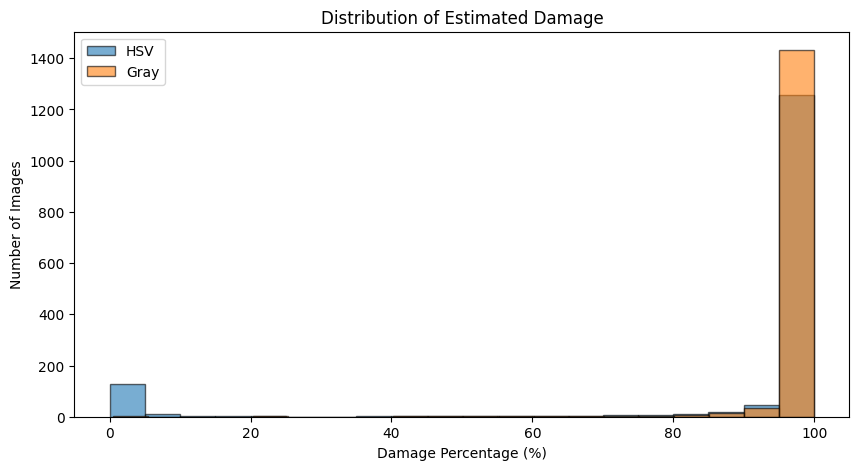

Histogram saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/damage_histograms.png


In [16]:
plt.figure(figsize=(10,5))
plt.hist(df['HSV Damage (%)'], bins=20, alpha=0.6, label='HSV', edgecolor='k')
plt.hist(df['Gray Damage (%)'], bins=20, alpha=0.6, label='Gray', edgecolor='k')
plt.xlabel('Damage Percentage (%)')
plt.ylabel('Number of Images')
plt.title('Distribution of Estimated Damage')
plt.legend()

hist_path = os.path.join(OUTPUT_DIR, "damage_histograms.png")
plt.savefig(hist_path, bbox_inches='tight')
plt.show()
print(f"Histogram saved to: {hist_path}")


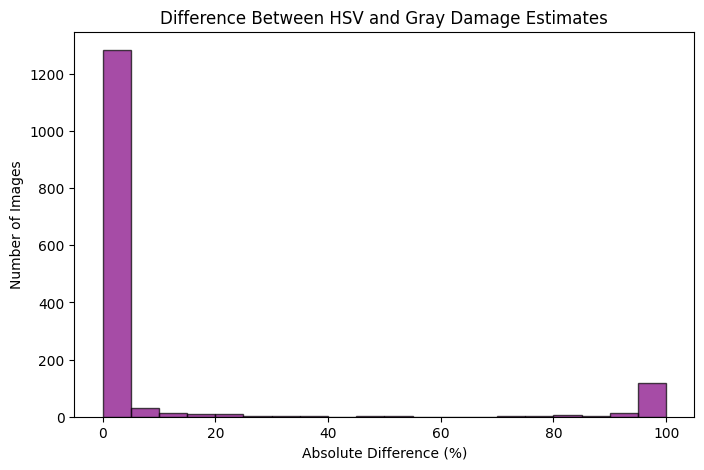

Difference distribution saved to: /content/drive/MyDrive/segmented EVALUATION_RESULTS 1/difference_distribution.png


In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Difference'], bins=20, color='purple', alpha=0.7, edgecolor='k')
plt.xlabel('Absolute Difference (%)')
plt.ylabel('Number of Images')
plt.title('Difference Between HSV and Gray Damage Estimates')

diff_path = os.path.join(OUTPUT_DIR, "difference_distribution.png")
plt.savefig(diff_path, bbox_inches='tight')
plt.show()
print(f"Difference distribution saved to: {diff_path}")


In [18]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import random

def silhouette_analysis(image_bgr, max_k=6, sample_size=2000):

    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    pixels = image_hsv.reshape(-1, 3)


    if len(pixels) > sample_size:
        pixels = pixels[random.sample(range(len(pixels)), sample_size)]

    scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels)
        score = silhouette_score(pixels, labels)
        scores.append(score)
        print(f"K = {k} → Silhouette Score = {score:.3f}")

    plt.figure(figsize=(6,4))
    plt.plot(range(2, max_k + 1), scores, marker='o', color='green')
    plt.title("Silhouette Analysis for Mango Segmentation")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Average Silhouette Score")
    plt.grid(True)
    plt.show()


    best_k = 2 + np.argmax(scores)
    print(f" Best K = {best_k} (Score = {max(scores):.3f})")
    return best_k

Running silhouette analysis on: /content/drive/MyDrive/BAD MANGOES1/822.jpg
K = 2 → Silhouette Score = 0.653
K = 3 → Silhouette Score = 0.737
K = 4 → Silhouette Score = 0.742
K = 5 → Silhouette Score = 0.733
K = 6 → Silhouette Score = 0.730


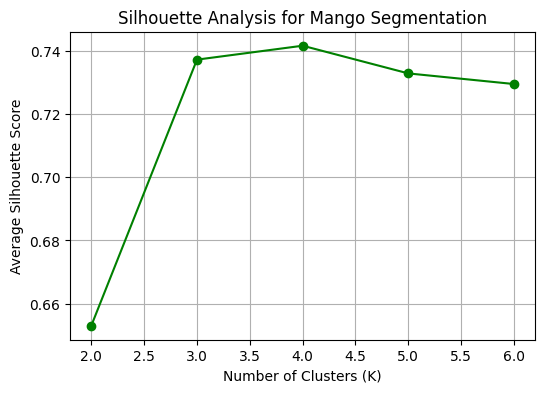

 Best K = 4 (Score = 0.742)


In [19]:
import cv2
IMAGE_DIR = "/content/drive/MyDrive/BAD MANGOES1"
#
sample_image_path = os.path.join(IMAGE_DIR, os.listdir(IMAGE_DIR)[0])
sample_image = cv2.imread(sample_image_path)

print("Running silhouette analysis on:", sample_image_path)
best_k = silhouette_analysis(sample_image, max_k=6)

Running silhouette analysis on 8 sample images...

Image 1/8: 422.jpg
   → Best K = 4 | Silhouette = 0.711

Image 2/8: 484.jpg
   → Best K = 4 | Silhouette = 0.748

Image 3/8: 167.jpg
   → Best K = 3 | Silhouette = 0.733

Image 4/8: 799.jpg
   → Best K = 3 | Silhouette = 0.748

Image 5/8: 368.jpg
   → Best K = 6 | Silhouette = 0.684

Image 6/8: 87.jpg
   → Best K = 5 | Silhouette = 0.744

Image 7/8: 120.jpg
   → Best K = 4 | Silhouette = 0.647

Image 8/8: 1393.jpg
   → Best K = 4 | Silhouette = 0.680

Average Best K across dataset = 4.12
Average Silhouette Score = 0.712


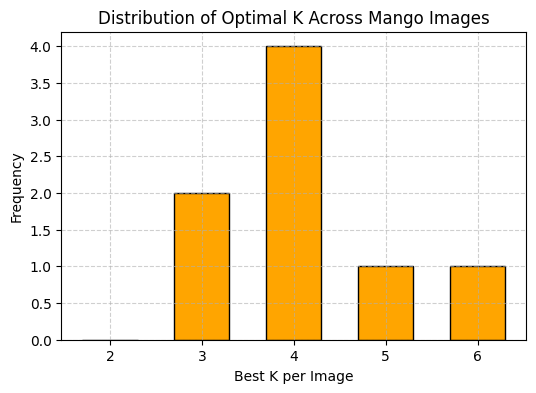

([np.int64(4),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(6),
  np.int64(5),
  np.int64(4),
  np.int64(4)],
 [np.float64(0.710866202159377),
  np.float64(0.748312632581634),
  np.float64(0.7329877352777797),
  np.float64(0.7476571536737793),
  np.float64(0.6841823136462163),
  np.float64(0.7440952856484228),
  np.float64(0.6470395964907528),
  np.float64(0.6800870350146685)])

In [20]:
import random

def batch_silhouette_analysis(image_dir=IMAGE_DIR, max_images=10, max_k=6):

    image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir)
                   if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    if len(image_files) == 0:
        print(" No images found in the folder.")
        return

    sample_files = random.sample(image_files, min(max_images, len(image_files)))
    print(f"Running silhouette analysis on {len(sample_files)} sample images...\n")

    all_best_k = []
    all_scores = []

    for i, img_path in enumerate(sample_files, 1):
        print(f"Image {i}/{len(sample_files)}: {os.path.basename(img_path)}")
        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            print("Could not read image.")
            continue
        image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
        pixels = image_hsv.reshape(-1, 3)
        sample_size = 2000
        if len(pixels) > sample_size:
            pixels = pixels[random.sample(range(len(pixels)), sample_size)]

        scores = []
        for k in range(2, max_k + 1):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(pixels)
            score = silhouette_score(pixels, labels)
            scores.append(score)

        best_k = 2 + np.argmax(scores)
        best_score = max(scores)
        all_best_k.append(best_k)
        all_scores.append(best_score)

        print(f"   → Best K = {best_k} | Silhouette = {best_score:.3f}\n")

    avg_k = np.mean(all_best_k)
    avg_score = np.mean(all_scores)


    print(f"Average Best K across dataset = {avg_k:.2f}")
    print(f"Average Silhouette Score = {avg_score:.3f}")

    plt.figure(figsize=(6,4))
    plt.hist(all_best_k, bins=np.arange(2, max_k+2)-0.5, rwidth=0.6, color='orange', edgecolor='black')
    plt.xticks(range(2, max_k+1))
    plt.xlabel("Best K per Image")
    plt.ylabel("Frequency")
    plt.title("Distribution of Optimal K Across Mango Images")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return all_best_k, all_scores
batch_silhouette_analysis(IMAGE_DIR, max_images=8, max_k=6)


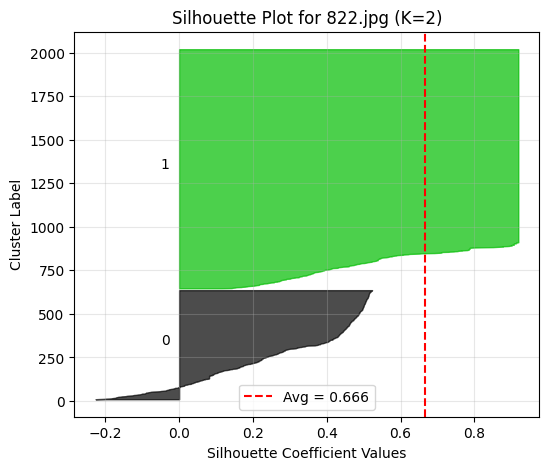

Average silhouette for 822.jpg = 0.666


np.float64(0.666115699412582)

In [21]:
from sklearn.metrics import silhouette_samples

def visualize_silhouette_for_image(image_path, k=2, sample_size=2000):
    """
    Visualize silhouette scores for one mango image and chosen number of clusters (k).
    """
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        print("Could not load image:", image_path)
        return
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    pixels = image_hsv.reshape(-1, 3)
    if len(pixels) > sample_size:
        pixels = pixels[random.sample(range(len(pixels)), sample_size)]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)

    silhouette_vals = silhouette_samples(pixels, labels)
    silhouette_avg = silhouette_vals.mean()
    y_lower = 10
    fig, ax = plt.subplots(figsize=(6, 5))
    for i in range(k):
        cluster_vals = silhouette_vals[labels == i]
        cluster_vals.sort()
        y_upper = y_lower + len(cluster_vals)
        color = plt.cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(i))
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg = {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    ax.set_title(f"Silhouette Plot for {os.path.basename(image_path)} (K={k})")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

    print(f"Average silhouette for {os.path.basename(image_path)} = {silhouette_avg:.3f}")
    return silhouette_avg

sample_image_path = os.path.join(IMAGE_DIR, os.listdir(IMAGE_DIR)[0])
visualize_silhouette_for_image(sample_image_path, k=2)


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering_metrics(pixels, labels):
    sil = silhouette_score(pixels, labels)
    ch = calinski_harabasz_score(pixels, labels)
    db = davies_bouldin_score(pixels, labels)
    print(f"Silhouette Score: {sil:.3f}")
    print(f"Calinski–Harabasz Index: {ch:.3f}")
    print(f"Davies–Bouldin Index: {db:.3f}")
    return sil, ch, db

# Example usage:
image_bgr = cv2.imread(os.path.join(IMAGE_DIR, os.listdir(IMAGE_DIR)[0]))
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
pixels = image_hsv.reshape(-1, 3)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)

evaluate_clustering_metrics(pixels, labels)


Silhouette Score: 0.654
Calinski–Harabasz Index: 60530.597
Davies–Bouldin Index: 0.790


(np.float64(0.6536592655761184),
 np.float64(60530.59749732159),
 np.float64(0.7903461745779596))

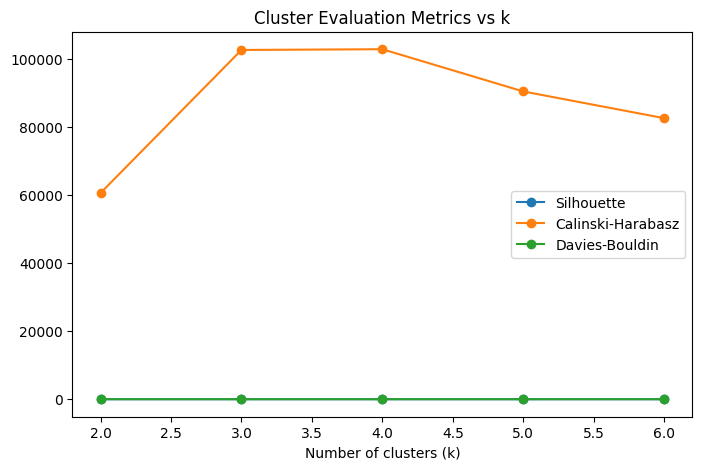

In [ ]:
sil_scores = []
ch_scores = []
db_scores = []
K = range(2, 7)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)
    sil_scores.append(silhouette_score(pixels, labels))
    ch_scores.append(calinski_harabasz_score(pixels, labels))
    db_scores.append(davies_bouldin_score(pixels, labels))

plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, 'o-', label='Silhouette')
plt.plot(K, ch_scores, 'o-', label='Calinski-Harabasz')
plt.plot(K, db_scores, 'o-', label='Davies-Bouldin')
plt.xlabel("Number of clusters (k)")
plt.legend()
plt.title("Cluster Evaluation Metrics vs k")
plt.show()
